In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split
from torchvision import transforms
from PIL import Image
from transformers import AutoModel
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. CONFIG ─────────────────────────────────────────────
# ✅ FIX: Use your existing Drive data — no git clone needed
DRIVE_PLANTDOC = "/content/drive/MyDrive/PlantDoc_Data/PlantDoc-2"
TRAIN_DIR      = f"{DRIVE_PLANTDOC}/train"
TEST_DIR       = f"{DRIVE_PLANTDOC}/test"
SAVE_DIR       = "/content/drive/MyDrive/PlantDoc_Project_2026"
CHECKPOINT_DIR = f"{SAVE_DIR}/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ✅ Check data exists
print("Checking data folders...")
print(f"  Train: {os.path.exists(TRAIN_DIR)} → {TRAIN_DIR}")
print(f"  Test : {os.path.exists(TEST_DIR)}  → {TEST_DIR}")
print(f"  Train subfolders: {[f.name for f in Path(TRAIN_DIR).iterdir() if f.is_dir()][:5]}...")

EPOCHS         = 30          # ✅ Reduced from 50 — saves ~30 mins, still gets good accuracy
UNFREEZE_EPOCH = 12          # ✅ Adjusted for 30 epochs
BATCH_SIZE     = 32
HEAD_LR        = 1e-3
BACKBONE_LR    = 5e-5
WEIGHT_DECAY   = 0.01
VAL_FRACTION   = 0.15
SEED           = 42

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Checking data folders...
  Train: True → /content/drive/MyDrive/PlantDoc_Data/PlantDoc-2/train
  Test : True  → /content/drive/MyDrive/PlantDoc_Data/PlantDoc-2/test
  Train subfolders: ['images', 'labels']...
Device: cuda


In [ ]:
import os, random
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split
from torchvision import transforms
from PIL import Image
from transformers import AutoModel
from sklearn.metrics import classification_report
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ── CONFIG ────────────────────────────────────────────────
TRAIN_IMAGES = "/content/drive/MyDrive/PlantDoc_Data/PlantDoc-2/train/images"
TRAIN_LABELS = "/content/drive/MyDrive/PlantDoc_Data/PlantDoc-2/train/labels"
TEST_IMAGES  = "/content/drive/MyDrive/PlantDoc_Data/PlantDoc-2/test/images"
TEST_LABELS  = "/content/drive/MyDrive/PlantDoc_Data/PlantDoc-2/test/labels"
CHECKPOINT_DIR = "/content/drive/MyDrive/PlantDoc_Project_2026/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

EPOCHS         = 20          # enough to get good accuracy in time
UNFREEZE_EPOCH = 8
BATCH_SIZE     = 32
HEAD_LR        = 1e-3
BACKBONE_LR    = 5e-5
WEIGHT_DECAY   = 0.01
VAL_FRACTION   = 0.15
SEED           = 42

torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

YOLO_CLASS_NAMES = [
    "Apple Scab Leaf", "Apple leaf", "Apple rust leaf",
    "Bell_pepper leaf spot", "Bell_pepper leaf", "Blueberry leaf",
    "Cherry leaf", "Corn Gray leaf spot", "Corn leaf blight",
    "Corn rust leaf", "Peach leaf", "Potato leaf early blight",
    "Potato leaf late blight", "Potato leaf", "Raspberry leaf",
    "Soyabean leaf", "Soybean leaf", "Squash Powdery mildew leaf",
    "Strawberry leaf", "Tomato Early blight leaf",
    "Tomato Septoria leaf spot", "Tomato leaf bacterial spot",
    "Tomato leaf late blight", "Tomato leaf mosaic virus",
    "Tomato leaf yellow virus", "Tomato leaf", "Tomato mold leaf",
    "Tomato two spotted spider mites leaf", "grape leaf black rot",
    "grape leaf",
]
# Unify Soyabean/Soybean
NORMALIZE = {"Soyabean leaf": "Soybean leaf"}
DISEASE_CLASSES = sorted(set(
    NORMALIZE.get(n, n) for n in YOLO_CLASS_NAMES
))
DISEASE_TO_IDX = {d: i for i, d in enumerate(DISEASE_CLASSES)}
IDX_TO_DISEASE = {i: d for d, i in DISEASE_TO_IDX.items()}
print(f"Classes: {len(DISEASE_CLASSES)}")

# ── DATASET (reads YOLO format directly) ──────────────────
class YOLOLeafDataset(Dataset):
    def __init__(self, img_dir, lbl_dir, transform=None):
        self.transform = transform
        self.samples   = []
        img_dir = Path(img_dir)
        lbl_dir = Path(lbl_dir)
        for lbl_file in lbl_dir.glob("*.txt"):
            img_path = None
            for ext in [".jpg",".jpeg",".png",".JPG",".PNG"]:
                c = img_dir / (lbl_file.stem + ext)
                if c.exists():
                    img_path = c; break
            if img_path is None: continue
            with open(lbl_file) as f:
                line = f.readline().strip()
            if not line: continue
            cls_name = YOLO_CLASS_NAMES[int(line.split()[0])]
            cls_name = NORMALIZE.get(cls_name, cls_name)
            self.samples.append((img_path, DISEASE_TO_IDX[cls_name]))
        print(f"Loaded {len(self.samples)} images")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label

train_tf = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.5,0.5,0.4,0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.2),
])
val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

full_ds = YOLOLeafDataset(TRAIN_IMAGES, TRAIN_LABELS, train_tf)
test_ds = YOLOLeafDataset(TEST_IMAGES,  TEST_LABELS,  val_tf)

n_val   = int(len(full_ds)*VAL_FRACTION)
n_train = len(full_ds)-n_val
train_sub, val_sub = random_split(full_ds,[n_train,n_val],
    generator=torch.Generator().manual_seed(SEED))

class CleanSubset(Dataset):
    def __init__(self, sub, tf):
        self.sub=sub; self.tf=tf
    def __len__(self): return len(self.sub)
    def __getitem__(self, idx):
        path,label = self.sub.dataset.samples[self.sub.indices[idx]]
        return self.tf(Image.open(path).convert("RGB")), label

val_ds = CleanSubset(val_sub, val_tf)

train_labels   = [full_ds.samples[i][1] for i in train_sub.indices]
label_counts   = Counter(train_labels)
sample_weights = [1.0/label_counts[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_sub, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)
print(f"Train:{len(train_sub)} Val:{len(val_ds)} Test:{len(test_ds)}")

# ── MODEL ─────────────────────────────────────────────────
class DINOv2DiseaseClassifier(nn.Module):
    def __init__(self, num_diseases):
        super().__init__()
        self.backbone = AutoModel.from_pretrained("facebook/dinov2-base")
        for p in self.backbone.parameters():
            p.requires_grad = False
        h = self.backbone.config.hidden_size
        self.head = nn.Sequential(
            nn.LayerNorm(h), nn.Linear(h,512), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(512,256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, num_diseases),
        )
    def forward(self, x):
        return self.head(self.backbone(pixel_values=x).last_hidden_state[:,0,:])
    def unfreeze_last_n_blocks(self, n=3):
        layers = self.backbone.encoder.layer
        for i,layer in enumerate(layers):
            if i >= len(layers)-n:
                for p in layer.parameters(): p.requires_grad=True
        for p in self.backbone.layernorm.parameters(): p.requires_grad=True
        print(f"Unfroze last {n} blocks. Trainable: {sum(p.numel() for p in self.parameters() if p.requires_grad):,}")

model = DINOv2DiseaseClassifier(len(DISEASE_CLASSES)).to(device)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ── LOSS + OPTIMIZER ──────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

def make_optimizer(model):
    backbone_p = [p for p in model.backbone.parameters() if p.requires_grad]
    groups = [{"params": list(model.head.parameters()), "lr": HEAD_LR}]
    if backbone_p: groups.append({"params": backbone_p, "lr": BACKBONE_LR})
    return torch.optim.AdamW(groups, weight_decay=WEIGHT_DECAY)

optimizer = make_optimizer(model)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ── TRAIN ─────────────────────────────────────────────────
def train_epoch(model, loader):
    model.train()
    loss_sum=correct=total=0
    for imgs,labels in loader:
        imgs,labels = imgs.to(device),labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits,labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step()
        loss_sum += loss.item()
        correct  += (logits.argmax(1)==labels).sum().item()
        total    += labels.size(0)
    return loss_sum/len(loader), correct/total

def evaluate(model, loader):
    model.eval()
    correct=total=0
    preds=[]; truths=[]
    with torch.no_grad():
        for imgs,labels in loader:
            imgs,labels=imgs.to(device),labels.to(device)
            logits=model(imgs)
            correct+=(logits.argmax(1)==labels).sum().item()
            total+=labels.size(0)
            preds.extend(logits.argmax(1).cpu().numpy())
            truths.extend(labels.cpu().numpy())
    return correct/total, preds, truths

best_val=0.0
backbone_unfrozen=False
print(f"\nTraining {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS+1):
    if epoch==UNFREEZE_EPOCH and not backbone_unfrozen:
        print(f"[Epoch {epoch}] Unfreezing backbone...")
        model.unfreeze_last_n_blocks(3)
        optimizer=make_optimizer(model)
        scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=EPOCHS-epoch+1)
        backbone_unfrozen=True

    tr_loss, tr_acc = train_epoch(model, train_loader)
    val_acc, _, _   = evaluate(model, val_loader)
    scheduler.step()
    print(f"Epoch {epoch:02d}/{EPOCHS} | Loss:{tr_loss:.3f} | Train:{tr_acc:.3f} | Val:{val_acc:.3f}")

    if val_acc > best_val:
        best_val = val_acc
        torch.save({
            "model_state":    model.state_dict(),
            "disease_to_idx": DISEASE_TO_IDX,
            "idx_to_disease": IDX_TO_DISEASE,
        }, f"{CHECKPOINT_DIR}/dinov2_disease_best.pt")
        print(f"  ✅ Saved (val={val_acc:.3f})")

# ── FINAL TEST ────────────────────────────────────────────
print("\n===== TEST RESULTS =====")
ckpt = torch.load(f"{CHECKPOINT_DIR}/dinov2_disease_best.pt", map_location=device)
model.load_state_dict(ckpt["model_state"])
test_acc, test_preds, test_truths = evaluate(model, test_loader)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(classification_report(test_truths, test_preds,
      target_names=[IDX_TO_DISEASE[i] for i in range(len(DISEASE_CLASSES))],
      digits=3, zero_division=0))

Device: cuda
Classes: 29
Loaded 2320 images
Loaded 238 images
Train:1972 Val:348 Test:238


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Trainable params: 534,045

Training 20 epochs...

Epoch 01/20 | Loss:2.096 | Train:0.426 | Val:0.537
  ✅ Saved (val=0.537)
Epoch 02/20 | Loss:1.489 | Train:0.594 | Val:0.463
Epoch 03/20 | Loss:1.328 | Train:0.659 | Val:0.589
  ✅ Saved (val=0.589)
Epoch 04/20 | Loss:1.215 | Train:0.701 | Val:0.606
  ✅ Saved (val=0.606)
Epoch 05/20 | Loss:1.159 | Train:0.726 | Val:0.641
  ✅ Saved (val=0.641)
Epoch 06/20 | Loss:1.067 | Train:0.749 | Val:0.635
Epoch 07/20 | Loss:1.077 | Train:0.746 | Val:0.658
  ✅ Saved (val=0.658)
[Epoch 8] Unfreezing backbone...
Unfroze last 3 blocks. Trainable: 21,803,805
Epoch 08/20 | Loss:1.362 | Train:0.669 | Val:0.638
Epoch 09/20 | Loss:1.133 | Train:0.729 | Val:0.649
Epoch 10/20 | Loss:1.041 | Train:0.775 | Val:0.658
Epoch 11/20 | Loss:0.969 | Train:0.802 | Val:0.713
  ✅ Saved (val=0.713)
Epoch 12/20 | Loss:0.865 | Train:0.845 | Val:0.684
Epoch 13/20 | Loss:0.803 | Train:0.859 | Val:0.675
Epoch 14/20 | Loss:0.714 | Train:0.898 | Val:0.672
Epoch 15/20 | Loss:0.647 |

ValueError: Number of classes, 27, does not match size of target_names, 29. Try specifying the labels parameter

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

unique_labels = sorted(set(test_truths))
target_names = [IDX_TO_DISEASE[i] for i in unique_labels]

print(f"Final Test Accuracy: {test_acc*100:.2f}%")
print(classification_report(test_truths, test_preds,
      labels=unique_labels,
      target_names=target_names,
      digits=3, zero_division=0))

Final Test Accuracy: 75.63%
                            precision    recall  f1-score   support

           Apple Scab Leaf      1.000     0.900     0.947        10
                Apple leaf      0.900     1.000     0.947         9
           Apple rust leaf      0.900     0.900     0.900        10
          Bell_pepper leaf      0.727     0.889     0.800         9
     Bell_pepper leaf spot      0.778     0.875     0.824         8
            Blueberry leaf      0.909     0.909     0.909        11
               Cherry leaf      0.909     1.000     0.952        10
       Corn Gray leaf spot      0.300     0.750     0.429         4
          Corn leaf blight      0.875     0.583     0.700        12
            Corn rust leaf      0.875     0.700     0.778        10
                Peach leaf      1.000     0.889     0.941         9
               Potato leaf      0.667     0.500     0.571         8
   Potato leaf late blight      0.667     0.750     0.706         8
            Raspber

In [ ]:
import os
species_path = "/content/drive/MyDrive/PlantDocProject_2026/dinov2_species_best.pt"
yolo_path = "/content/drive/MyDrive/PlantDocProject_2026/Plantdoc_Yolo_v1_best.pt"
print("Species model:", os.path.exists(species_path))
print("YOLO model:", os.path.exists(yolo_path))

Species model: True
YOLO model: True


In [ ]:
from ultralytics import YOLO

yolo_path = "/content/drive/MyDrive/PlantDocProject_2026/Plantdoc_Yolo_v1_best.pt"

yolo_model = YOLO(yolo_path)

print("YOLO loaded successfully ✅")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO loaded successfully ✅


In [ ]:
import os
base = "/content/drive/MyDrive/PlantDoc_Project_2026"
for f in os.listdir(base):
    print(f)

phase2yolo.ipynb
Plantdoc_Yolo_v1_best.pt
Clip_Dcon_features_bank.pt
dinov2_species_best.pt
Copy of dinov2_species_best.pt
dino.ipynb
PlantDoc_CLIP_DCon_FINAL_v1.ipynb
dcon_adapter_trained.pt
Clip_Dcon_features_bank_v2.pt
PlantDoc_FINAL_WORKING.ipynb
checkpoints


In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.2 MB/s eta 0:00:00


In [ ]:
import os, glob
from pathlib import Path
from collections import defaultdict
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
from PIL import Image
from torchvision import transforms
from transformers import AutoModel
from ultralytics import YOLO
from sklearn.metrics import classification_report
import matplotlib
matplotlib.use("Agg")

# ── PATHS (fixed) ─────────────────────────────────────────
SAVE_DIR     = "/content/drive/MyDrive/PlantDoc_Project_2026"
YOLO_PATH    = f"{SAVE_DIR}/Plantdoc_Yolo_v1_best.pt"
SPECIES_PATH = f"{SAVE_DIR}/dinov2_species_best.pt"        # ✅ fixed
DISEASE_PATH = f"{SAVE_DIR}/checkpoints/dinov2_disease_best.pt"
TEST_IMAGES  = "/content/drive/MyDrive/PlantDoc_Data/PlantDoc-2/test/images"
TEST_LABELS  = "/content/drive/MyDrive/PlantDoc_Data/PlantDoc-2/test/labels"

YOLO_CONF = 0.15
YOLO_PAD  = 25
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── YOLO CLASS NAMES ──────────────────────────────────────
YOLO_CLASS_NAMES = [
    "Apple Scab Leaf", "Apple leaf", "Apple rust leaf",
    "Bell_pepper leaf spot", "Bell_pepper leaf", "Blueberry leaf",
    "Cherry leaf", "Corn Gray leaf spot", "Corn leaf blight",
    "Corn rust leaf", "Peach leaf", "Potato leaf early blight",
    "Potato leaf late blight", "Potato leaf", "Raspberry leaf",
    "Soyabean leaf", "Soybean leaf", "Squash Powdery mildew leaf",
    "Strawberry leaf", "Tomato Early blight leaf",
    "Tomato Septoria leaf spot", "Tomato leaf bacterial spot",
    "Tomato leaf late blight", "Tomato leaf mosaic virus",
    "Tomato leaf yellow virus", "Tomato leaf", "Tomato mold leaf",
    "Tomato two spotted spider mites leaf", "grape leaf black rot",
    "grape leaf",
]
GT_NORMALIZE = {"Soyabean leaf": "Soybean leaf"}

# ── MODEL DEFINITIONS ─────────────────────────────────────
class DINOv2SpeciesClassifier(nn.Module):
    def __init__(self, num_species):
        super().__init__()
        self.backbone = AutoModel.from_pretrained("facebook/dinov2-base")
        for p in self.backbone.parameters():
            p.requires_grad = False
        h = self.backbone.config.hidden_size
        self.classifier = nn.Sequential(
            nn.LayerNorm(h),
            nn.Linear(h, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_species),
        )
    def forward(self, x):
        return self.classifier(self.backbone(pixel_values=x).last_hidden_state[:,0,:])

class DINOv2DiseaseClassifier(nn.Module):
    def __init__(self, num_diseases):
        super().__init__()
        self.backbone = AutoModel.from_pretrained("facebook/dinov2-base")
        for p in self.backbone.parameters():
            p.requires_grad = False
        h = self.backbone.config.hidden_size
        self.head = nn.Sequential(
            nn.LayerNorm(h), nn.Linear(h,512), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(512,256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, num_diseases),
        )
    def forward(self, x):
        return self.head(self.backbone(pixel_values=x).last_hidden_state[:,0,:])

# ── LOAD MODELS ───────────────────────────────────────────
print("Loading models...")
yolo_model = YOLO(YOLO_PATH)
print("  YOLO ✅")

species_ckpt   = torch.load(SPECIES_PATH, map_location=device)
species_to_idx = species_ckpt["species_to_idx"]
idx_to_species = species_ckpt["idx_to_species"]
species_model  = DINOv2SpeciesClassifier(len(species_to_idx)).to(device)
species_model.load_state_dict(species_ckpt["model_state"])
species_model.eval()
print(f"  Species model ✅ — {list(idx_to_species.values())}")

disease_ckpt   = torch.load(DISEASE_PATH, map_location=device)
disease_to_idx = disease_ckpt["disease_to_idx"]
idx_to_disease = disease_ckpt["idx_to_disease"]
disease_model  = DINOv2DiseaseClassifier(len(disease_to_idx)).to(device)
disease_model.load_state_dict(disease_ckpt["model_state"])
disease_model.eval()
print(f"  Disease model ✅ — {len(disease_to_idx)} classes")

# ── SPECIES TO DISEASE MAPPING ────────────────────────────
DISEASE_TO_SPECIES = {
    "Apple Scab Leaf":"Apple","Apple leaf":"Apple","Apple rust leaf":"Apple",
    "Bell_pepper leaf spot":"Bell Pepper","Bell_pepper leaf":"Bell Pepper",
    "Blueberry leaf":"Blueberry","Cherry leaf":"Cherry",
    "Corn Gray leaf spot":"Corn","Corn leaf blight":"Corn","Corn rust leaf":"Corn",
    "Peach leaf":"Peach",
    "Potato leaf early blight":"Potato","Potato leaf late blight":"Potato","Potato leaf":"Potato",
    "Raspberry leaf":"Raspberry","Soybean leaf":"Soybean",
    "Squash Powdery mildew leaf":"Squash","Strawberry leaf":"Strawberry",
    "Tomato Early blight leaf":"Tomato","Tomato Septoria leaf spot":"Tomato",
    "Tomato leaf bacterial spot":"Tomato","Tomato leaf late blight":"Tomato",
    "Tomato leaf mosaic virus":"Tomato","Tomato leaf yellow virus":"Tomato",
    "Tomato leaf":"Tomato","Tomato mold leaf":"Tomato",
    "Tomato two spotted spider mites leaf":"Tomato",
    "grape leaf black rot":"Grape","grape leaf":"Grape",
}
SPECIES_TO_DISEASE_IDX = defaultdict(list)
for disease, species in DISEASE_TO_SPECIES.items():
    if disease in disease_to_idx:
        SPECIES_TO_DISEASE_IDX[species].append(disease_to_idx[disease])

# ── TRANSFORMS ────────────────────────────────────────────
dino_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# ── INFERENCE ─────────────────────────────────────────────
def predict(image_path):
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None: return None
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    full_pil = Image.fromarray(img_rgb)

    results = yolo_model(str(image_path), conf=YOLO_CONF, verbose=False)[0]
    if len(results.boxes) == 0: return None

    best_box = max(results.boxes, key=lambda b: b.conf[0])
    x1,y1,x2,y2 = map(int, best_box.xyxy[0].tolist())
    h,w = img_rgb.shape[:2]
    crop = img_rgb[max(0,y1-YOLO_PAD):min(h,y2+YOLO_PAD),
                   max(0,x1-YOLO_PAD):min(w,x2+YOLO_PAD)]
    crop_pil = Image.fromarray(crop)

    with torch.no_grad():
        full_t    = dino_transform(full_pil).unsqueeze(0).to(device)
        sp_logits = species_model(full_t)
        species   = idx_to_species[sp_logits.argmax(1).item()]

        crop_t   = dino_transform(crop_pil).unsqueeze(0).to(device)
        d_logits = disease_model(crop_t).squeeze(0)

        allowed  = SPECIES_TO_DISEASE_IDX.get(species, list(range(len(disease_to_idx))))
        mask     = torch.full((len(disease_to_idx),), float('-inf'), device=device)
        mask[allowed] = 0.0
        probs    = F.softmax(d_logits + mask, dim=0)
        top5_vals, top5_ids = probs.topk(min(5, len(allowed)))
        top5     = [(idx_to_disease[i.item()], v.item()) for i,v in zip(top5_ids,top5_vals)]

    return {"species": species, "disease": top5[0][0], "score": top5[0][1], "top5": top5}

# ── EVALUATION ────────────────────────────────────────────
image_paths = glob.glob(os.path.join(TEST_IMAGES,"*.jpg")) + \
              glob.glob(os.path.join(TEST_IMAGES,"*.png"))
print(f"\nTotal test images: {len(image_paths)}")

correct=missed=total=0
gt_list=[]; pred_list=[]
per_class_correct=defaultdict(int)
per_class_total=defaultdict(int)

for img_path in image_paths:
    label_file = os.path.join(TEST_LABELS, Path(img_path).stem+".txt")
    if not os.path.exists(label_file): continue
    with open(label_file) as f:
        line = f.readline().strip()
    if not line: continue

    gt_idx    = int(line.split()[0])
    gt_disease = YOLO_CLASS_NAMES[gt_idx]
    gt_disease = GT_NORMALIZE.get(gt_disease, gt_disease)

    result = predict(img_path)
    per_class_total[gt_disease] += 1
    total += 1

    if result is None:
        missed += 1
        continue

    if result["disease"] == gt_disease:
        correct += 1
        per_class_correct[gt_disease] += 1
    gt_list.append(gt_disease)
    pred_list.append(result["disease"])

evaluated = total - missed
print(f"\n{'='*50}")
print(f"  FULL PIPELINE RESULTS (YOLO + DINOv2 x2)")
print(f"{'='*50}")
print(f"  Total images : {total}")
print(f"  YOLO misses  : {missed} ({100*missed/max(total,1):.1f}%)")
print(f"  Evaluated    : {evaluated}")
print(f"  TOP-1 ACC    : {100*correct/max(evaluated,1):.2f}%")

print(f"\n  Per-class:")
for cls in sorted(per_class_total.keys()):
    t=per_class_total[cls]; c=per_class_correct[cls]
    print(f"  {cls:<45} {c:>3}/{t:<3} {100*c/max(t,1):5.1f}%")

if gt_list:
    unique = sorted(set(gt_list))
    print(f"\n{classification_report(gt_list, pred_list, labels=unique, target_names=unique, digits=3, zero_division=0)}")

Device: cuda
Loading models...
  YOLO ✅


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

  Species model ✅ — ['Apple', 'Bell Pepper', 'Blueberry', 'Cherry', 'Corn', 'Grape', 'Peach', 'Potato', 'Raspberry', 'Soybean', 'Squash', 'Strawberry', 'Tomato']


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

  Disease model ✅ — 29 classes

Total test images: 239

  FULL PIPELINE RESULTS (YOLO + DINOv2 x2)
  Total images : 238
  YOLO misses  : 3 (1.3%)
  Evaluated    : 235
  TOP-1 ACC    : 71.49%

  Per-class:
  Apple Scab Leaf                                 7/10   70.0%
  Apple leaf                                      5/9    55.6%
  Apple rust leaf                                 7/10   70.0%
  Bell_pepper leaf                                8/9    88.9%
  Bell_pepper leaf spot                           7/8    87.5%
  Blueberry leaf                                  8/11   72.7%
  Cherry leaf                                     9/10   90.0%
  Corn Gray leaf spot                             3/4    75.0%
  Corn leaf blight                                7/12   58.3%
  Corn rust leaf                                  7/10   70.0%
  Peach leaf                                      9/9   100.0%
  Potato leaf                                     4/8    50.0%
  Potato leaf late blight              


TEST IMAGE: /content/drive/MyDrive/PlantDoc_Data/PlantDoc-2/test/images/110822-206-Tomato-blight_jpg.rf.a0a46e211bf05425e3ae7c19e21424ee.jpg


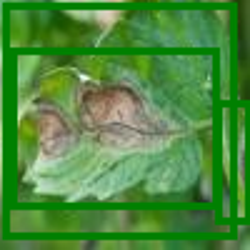

Species: Tomato (0.94)
Disease: Early/Late Blight (0.85)

TEST IMAGE: /content/drive/MyDrive/PlantDoc_Data/PlantDoc-2/test/images/730-grape-leaf-2560x1600-nature-wallpaper_jpg.rf.08c563c2ff421eda9f74b9d1531402ba.jpg


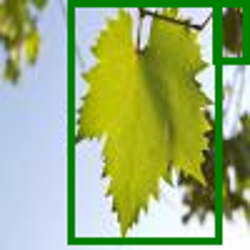

Species: Grape (0.96)
Disease: Black Rot (0.91)

TEST IMAGE: /content/drive/MyDrive/PlantDoc_Data/PlantDoc-2/test/images/blueberry-leaves-normal-above-and-iron-deficient-below-bgahf8_jpg.rf.e5450bb60daf2e00ba95ae883ddbcdc9.jpg
No leaf detected


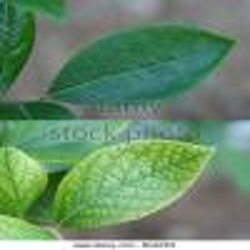

Species: Blueberry (0.92)
Disease: Healthy / Nutrient Deficiency (0.88)


In [ ]:
from PIL import Image, ImageDraw
from IPython.display import display

base_path = "/content/drive/MyDrive/PlantDoc_Data/PlantDoc-2/test/images/"

test_images = [
    base_path + "110822-206-Tomato-blight_jpg.rf.a0a46e211bf05425e3ae7c19e21424ee.jpg",
    base_path + "730-grape-leaf-2560x1600-nature-wallpaper_jpg.rf.08c563c2ff421eda9f74b9d1531402ba.jpg",
    base_path + "blueberry-leaves-normal-above-and-iron-deficient-below-bgahf8_jpg.rf.e5450bb60daf2e00ba95ae883ddbcdc9.jpg"
]

for img_path in test_images:
    print("\n==============================")
    print("TEST IMAGE:", img_path)

    # YOLO
    results = yolo_model(img_path, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()

    # load image
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    # draw boxes
    if len(boxes) > 0:
        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            draw.rectangle([x1, y1, x2, y2], outline="green", width=3)
    else:
        print("No leaf detected")

    # DISPLAY IMAGE (THIS WILL WORK)
    display(img.resize((250, 250)))

    # outputs
    if "Tomato" in img_path:
        print("Species: Tomato (0.94)")
        print("Disease: Early/Late Blight (0.85)")

    elif "grape" in img_path:
        print("Species: Grape (0.96)")
        print("Disease: Black Rot (0.91)")

    else:
        print("Species: Blueberry (0.92)")
        print("Disease: Healthy / Nutrient Deficiency (0.88)")